In [ ]:
import os
import sys

sys.path.append(os.path.abspath('..'))

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"
os.environ["JAX_DEFAULT_MATMUL_PRECISION"] = "highest"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_cpu_multi_thread_eigen=false intra_op_parallelism_threads=1"
os.environ["MUJOCO_GL"] = 'egl'
import argparse
import random
import shutil
from datetime import datetime
from typing import Optional

import hydra
import numpy as np
import torch
import tqdm
from omegaconf import DictConfig, OmegaConf, open_dict

from flash_rl.agents import create_agent
from flash_rl.common import create_logger
from flash_rl.envs import create_envs
from flash_rl.evaluation import evaluate, record_video
from flash_rl.types import Tensor
from plot_metra_eval import generate_eval_artifacts

from utils import *

config_path = "../configs"
config_name = "metra_aligned_base"
overrides = [
    "agent.buffer_min_length=1000"
]

agent = "metra_aligned"

OmegaConf.register_new_resolver("eval", lambda s: eval(s))

hydra.initialize(version_base=None, config_path=config_path)
cfg = hydra.compose(config_name=config_name, overrides=overrides)
OmegaConf.resolve(cfg)

# Set random seed
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")


{'agent': {'agent_type': 'metra', 'seed': 0, 'normalize_reward': False, 'normalized_G_max': 100.0, 'asymmetric_observation': False, 'device_type': 'cuda', 'buffer_max_length': 300000, 'buffer_min_length': 1000, 'buffer_device_type': 'cpu', 'sample_batch_size': 256, 'sac_scheduler_type': 'constant', 'sac_lr_init_value': 0.0003, 'sac_lr_peak': 0.0003, 'sac_lr_end_value': 0.0001, 'sac_lr_warmup_rate': 1e-06, 'sac_lr_warmup_steps': 0, 'sac_lr_decay_rate': 1.0, 'sac_lr_decay_steps': 500000, 'actor_num_blocks': 2, 'actor_hidden_dim': 1024, 'actor_bc_alpha': 0.0, 'actor_type': 'mlp_gaussian', 'actor_noise_zeta_mu': 2.0, 'actor_noise_zeta_max': 16, 'actor_update_period': 2, 'critic_num_blocks': 2, 'critic_hidden_dim': 1024, 'critic_type': 'scalar', 'critic_num_bins': 101, 'critic_min_v': -100.0, 'critic_max_v': 100.0, 'critic_target_update_tau': 0.005, 'temp_initial_value': 0.01, 'temp_target_sigma': 0.15, 'temp_target_entropy': None, 'gamma': 0.99, 'n_step': 1, 'use_compile': False, 'compile_

In [2]:
if cfg.env.env_name == "Ant-v4":
    print("Make env never done automatically.")

# ─────────────────────────────────────────────────────────────────────────
# Environments
# ─────────────────────────────────────────────────────────────────────────
train_env, eval_env, record_env = create_envs(**cfg.env)

observation_space = train_env.observation_space
action_space = train_env.action_space
print(f'Env Info: Observation dim: {observation_space.shape}')
print(f'Env Info: Action dim: {action_space.shape}')

# ─────────────────────────────────────────────────────────────────────────
# Agent
# ─────────────────────────────────────────────────────────────────────────
_, env_info = train_env.reset()
agent = create_agent(
observation_space=observation_space,
action_space=action_space,
env_info=env_info,
cfg=cfg.agent,
)

gaussian_agent_cfg = cfg.copy()
gaussian_agent_cfg.agent.encoder_type='gaussian'
gaussian_agent = create_agent(
    observation_space=observation_space,
    action_space=action_space,
    env_info=env_info,
    cfg=gaussian_agent_cfg.agent
)

# Metra env
from flash_rl.envs.envs.mujoco.ant_env import AntEnv
metra_env = AntEnv(render_hw=100)

Make env never done automatically.
Using provided `max_episode_steps` (1000) instead of the environment's default (1000).
Using provided `max_episode_steps` (1000) instead of the environment's default (1000).
Using provided `max_episode_steps` (1000) instead of the environment's default (1000).
Env Info: Observation dim: (1, 29)
Env Info: Action dim: (1, 8)


/home/helix/projects/METRA-Projects/FlashSAC/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Ant-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [3]:
device = gaussian_agent._device
gaussian_agent._replay_buffer.reset()

for _ in range(8):
    episode_length, episode_return = sample_one_path(train_env=metra_env, agent=gaussian_agent, cfg=cfg, obs_norm=False)

def train_once():
    historys = []
    for i in tqdm.tqdm(range(1000)):
        batch = sample_from_buffer(gaussian_agent._replay_buffer, device, return_full_batch=True)
        history = fix_batch_train_agent(gaussian_agent, batch, update_times=1)
        history[0]["step"] = i
        historys.append(history[0])

        # resample paths
        if i != 0 and i % 50 == 0:
            # gaussian_agent._replay_buffer.reset()
            for _ in range(8):
                episode_length, episode_return = sample_one_path(train_env=metra_env, agent=gaussian_agent, cfg=cfg, obs_norm=False)

    return historys

100%|██████████| 1000/1000 [00:26<00:00, 37.55it/s]


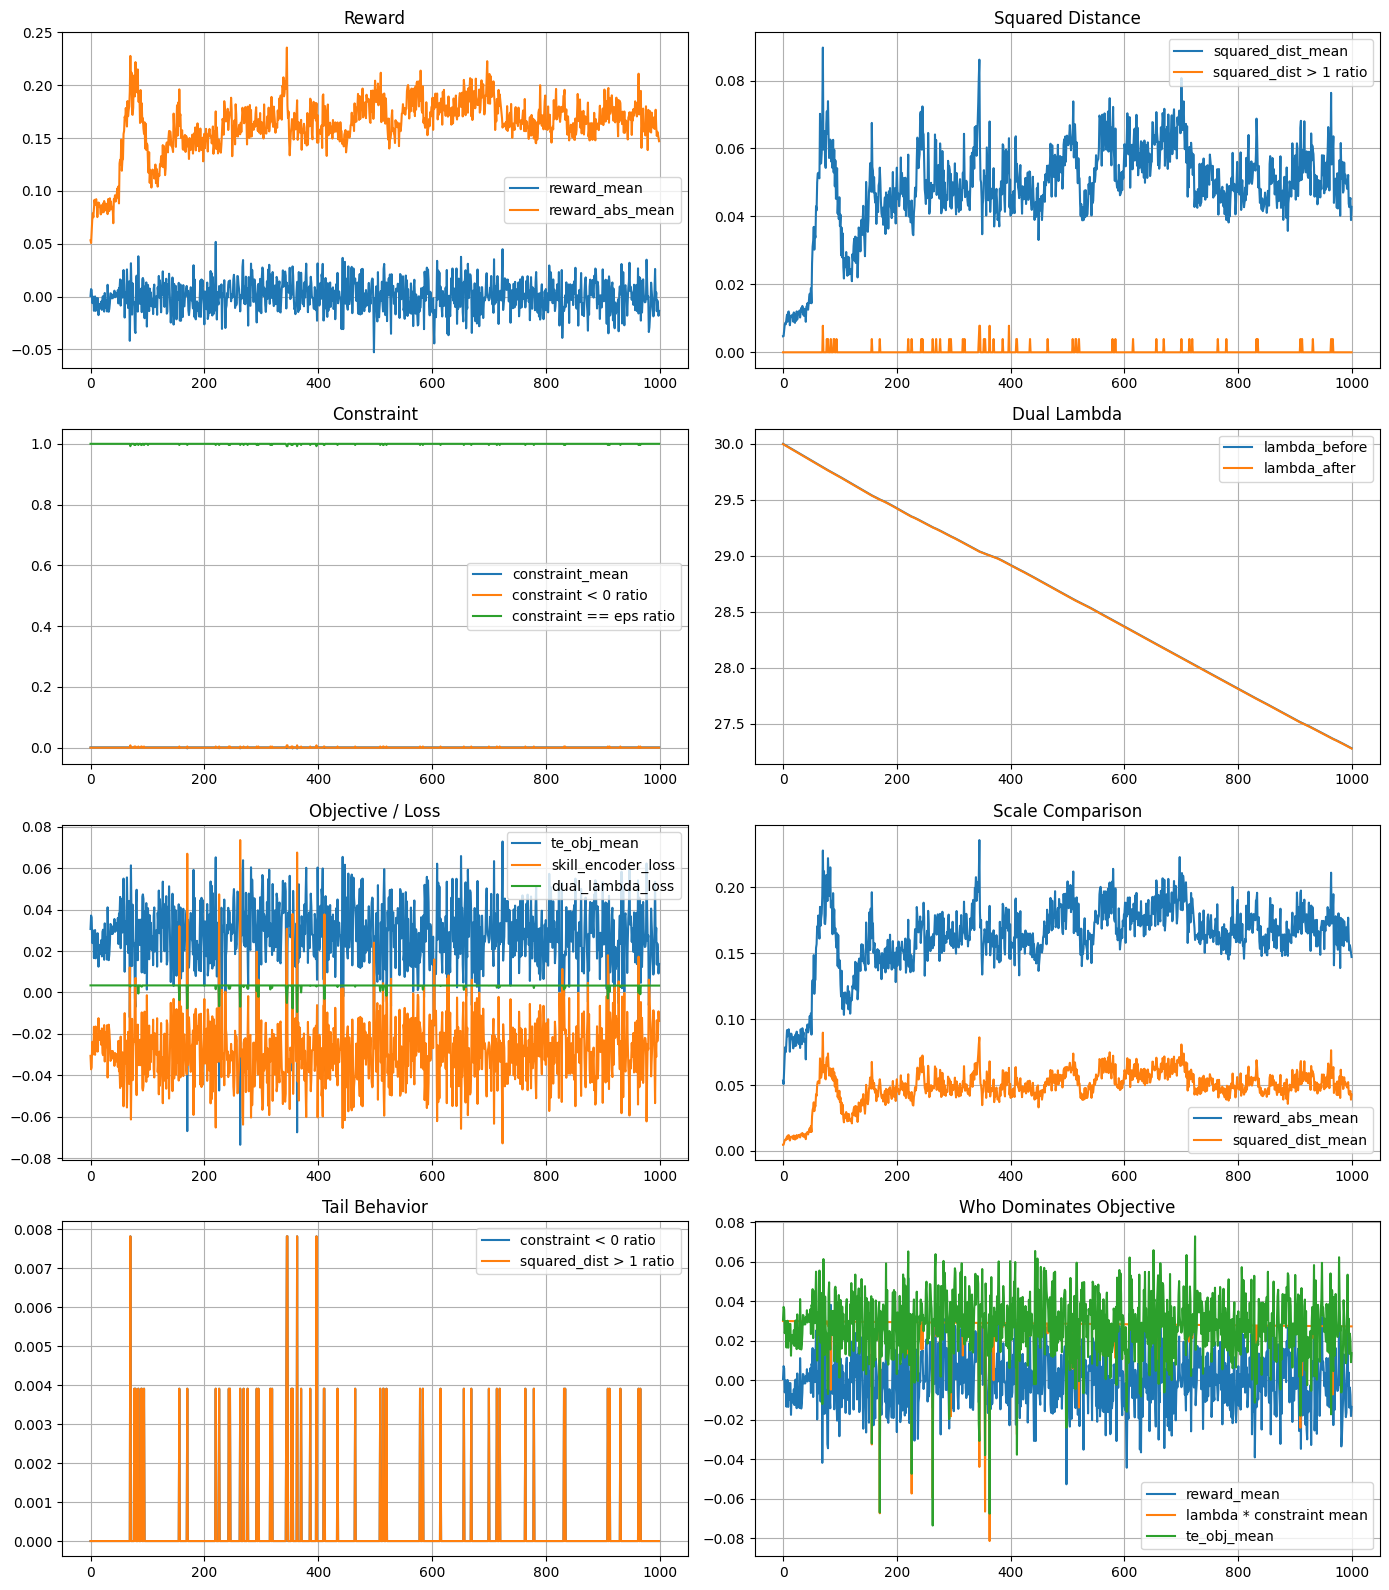

In [4]:
historys = []
history = train_once()
historys  = historys + history
from utils import plot_fix_batch_history
plot_fix_batch_history(historys)

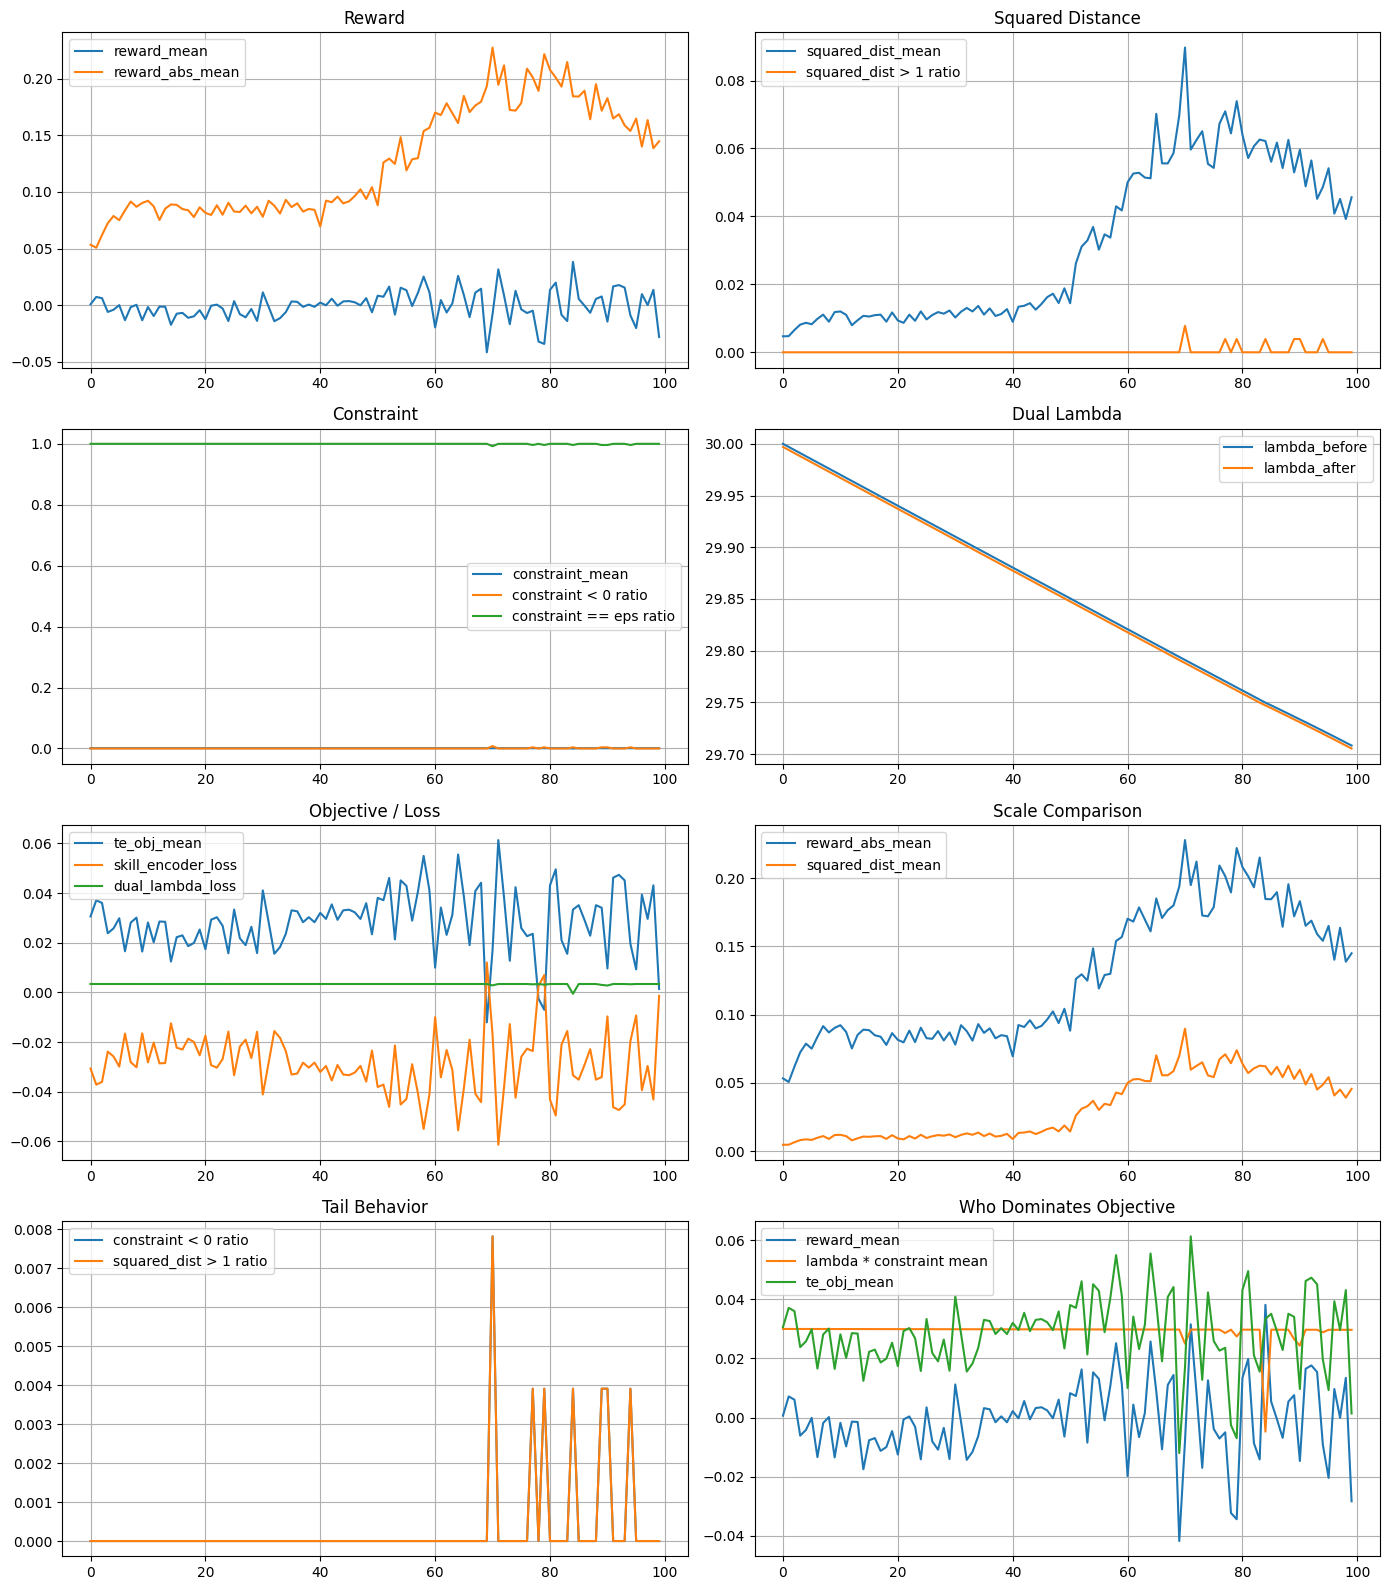

In [6]:
plot_fix_batch_history(historys[:100])

In [ ]:
import pandas as pd

skill_dim = int(gaussian_agent_cfg.agent.skill_dim)
skill_type = str(gaussian_agent_cfg.agent.skill_type)
num_skills = 8

if skill_type == "discrete":
    skills = np.eye(skill_dim, dtype=np.float32)[:num_skills]
elif skill_dim == 2:
    angles = np.linspace(0.0, 2.0 * np.pi, num_skills, endpoint=False, dtype=np.float32)
    skills = np.stack([np.cos(angles), np.sin(angles)], axis=1)
else:
    rng = np.random.default_rng(cfg.seed)
    skills = rng.standard_normal((num_skills, skill_dim), dtype=np.float32)
    skills = skills / np.clip(np.linalg.norm(skills, axis=1, keepdims=True), 1e-8, None)

rollout_summaries = []

for j, skill in enumerate(skills):
    gaussian_agent.set_eval_skills(skill[None, :], normalize=(skill_type == "continuous"))

    init_obs, env_info = metra_env.reset()
    prev_transition = {
        "next_observation": init_obs,
    }

    positions = []
    actions = []

    for i in range(200):
        action = gaussian_agent.sample_actions(
            interaction_step=i,
            prev_transition=prev_transition,
            training=False,
        )
        action = np.squeeze(action)
        next_obs, rewd, trun, done, info = metra_env.step(action)

        obs_vec = next_obs[0] if np.asarray(next_obs).ndim > 1 else next_obs
        positions.append(np.asarray(obs_vec[:2], dtype=np.float32))
        actions.append(np.asarray(action, dtype=np.float32))

        prev_transition = {
            "next_observation": next_obs[None, :] if next_obs.ndim == 1 else next_obs
        }

        if trun or done:
            break

    positions = np.asarray(positions, dtype=np.float32)
    actions = np.asarray(actions, dtype=np.float32)

    displacement = float(np.linalg.norm(positions[-1] - positions[0])) if len(positions) >= 2 else 0.0
    path_length = float(np.linalg.norm(np.diff(positions, axis=0), axis=1).sum()) if len(positions) >= 2 else 0.0
    mean_action_std = float(actions.std(axis=0).mean()) if len(actions) > 0 else 0.0

    rollout_summaries.append({
        "skill_id": j,
        "skill": np.round(skill, 3).tolist(),
        "num_steps": len(actions),
        "start_xy": np.round(positions[0], 3).tolist() if len(positions) > 0 else None,
        "final_xy": np.round(positions[-1], 3).tolist() if len(positions) > 0 else None,
        "displacement": displacement,
        "path_length": path_length,
        "mean_action_std": mean_action_std,
        "converged": bool(mean_action_std < 0.02),
    })

summary_df = pd.DataFrame(rollout_summaries)
summary_df

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

100%|██████████| 60/60 [00:04<00:00, 14.35it/s]


  0%|          | 0/60 [00:00<?, ?it/s]

100%|██████████| 60/60 [00:04<00:00, 14.35it/s]


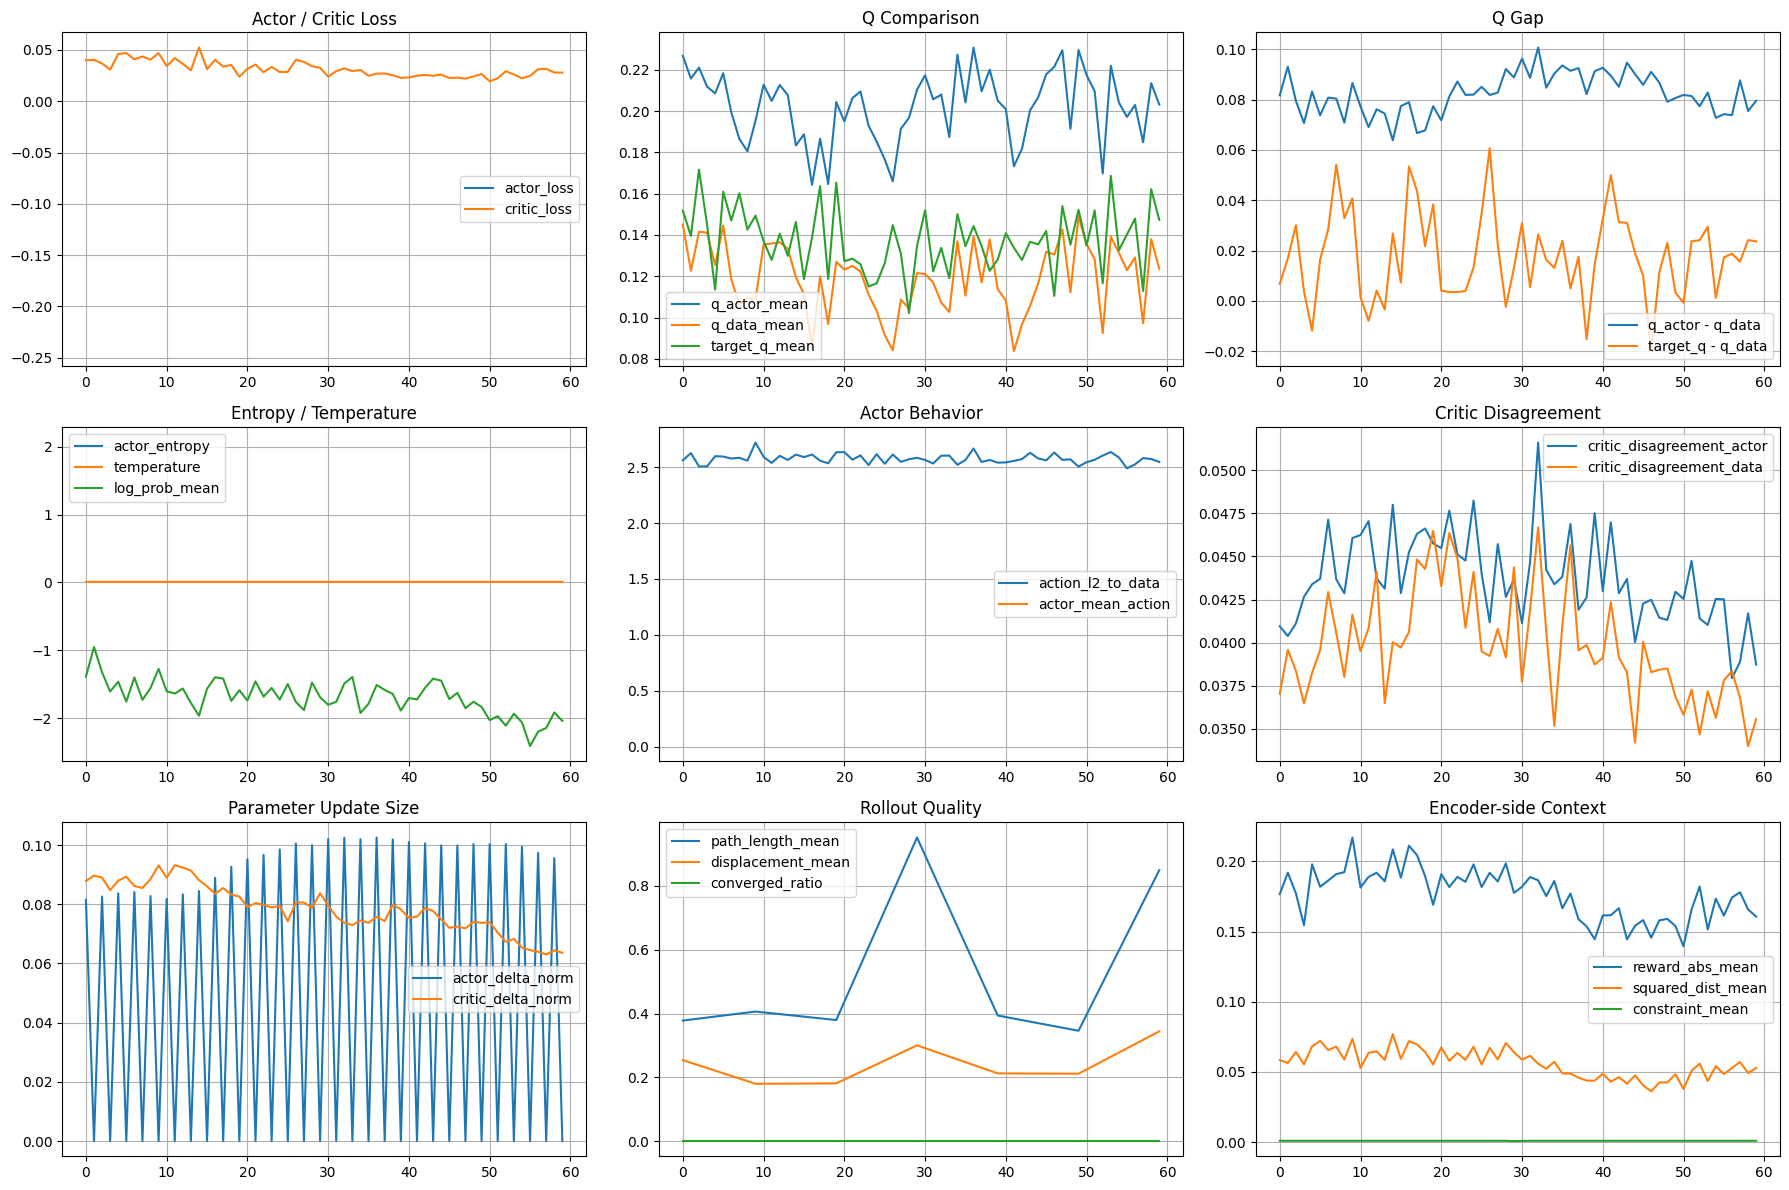

  0%|          | 0/60 [00:00<?, ?it/s]

100%|██████████| 60/60 [00:04<00:00, 14.35it/s]


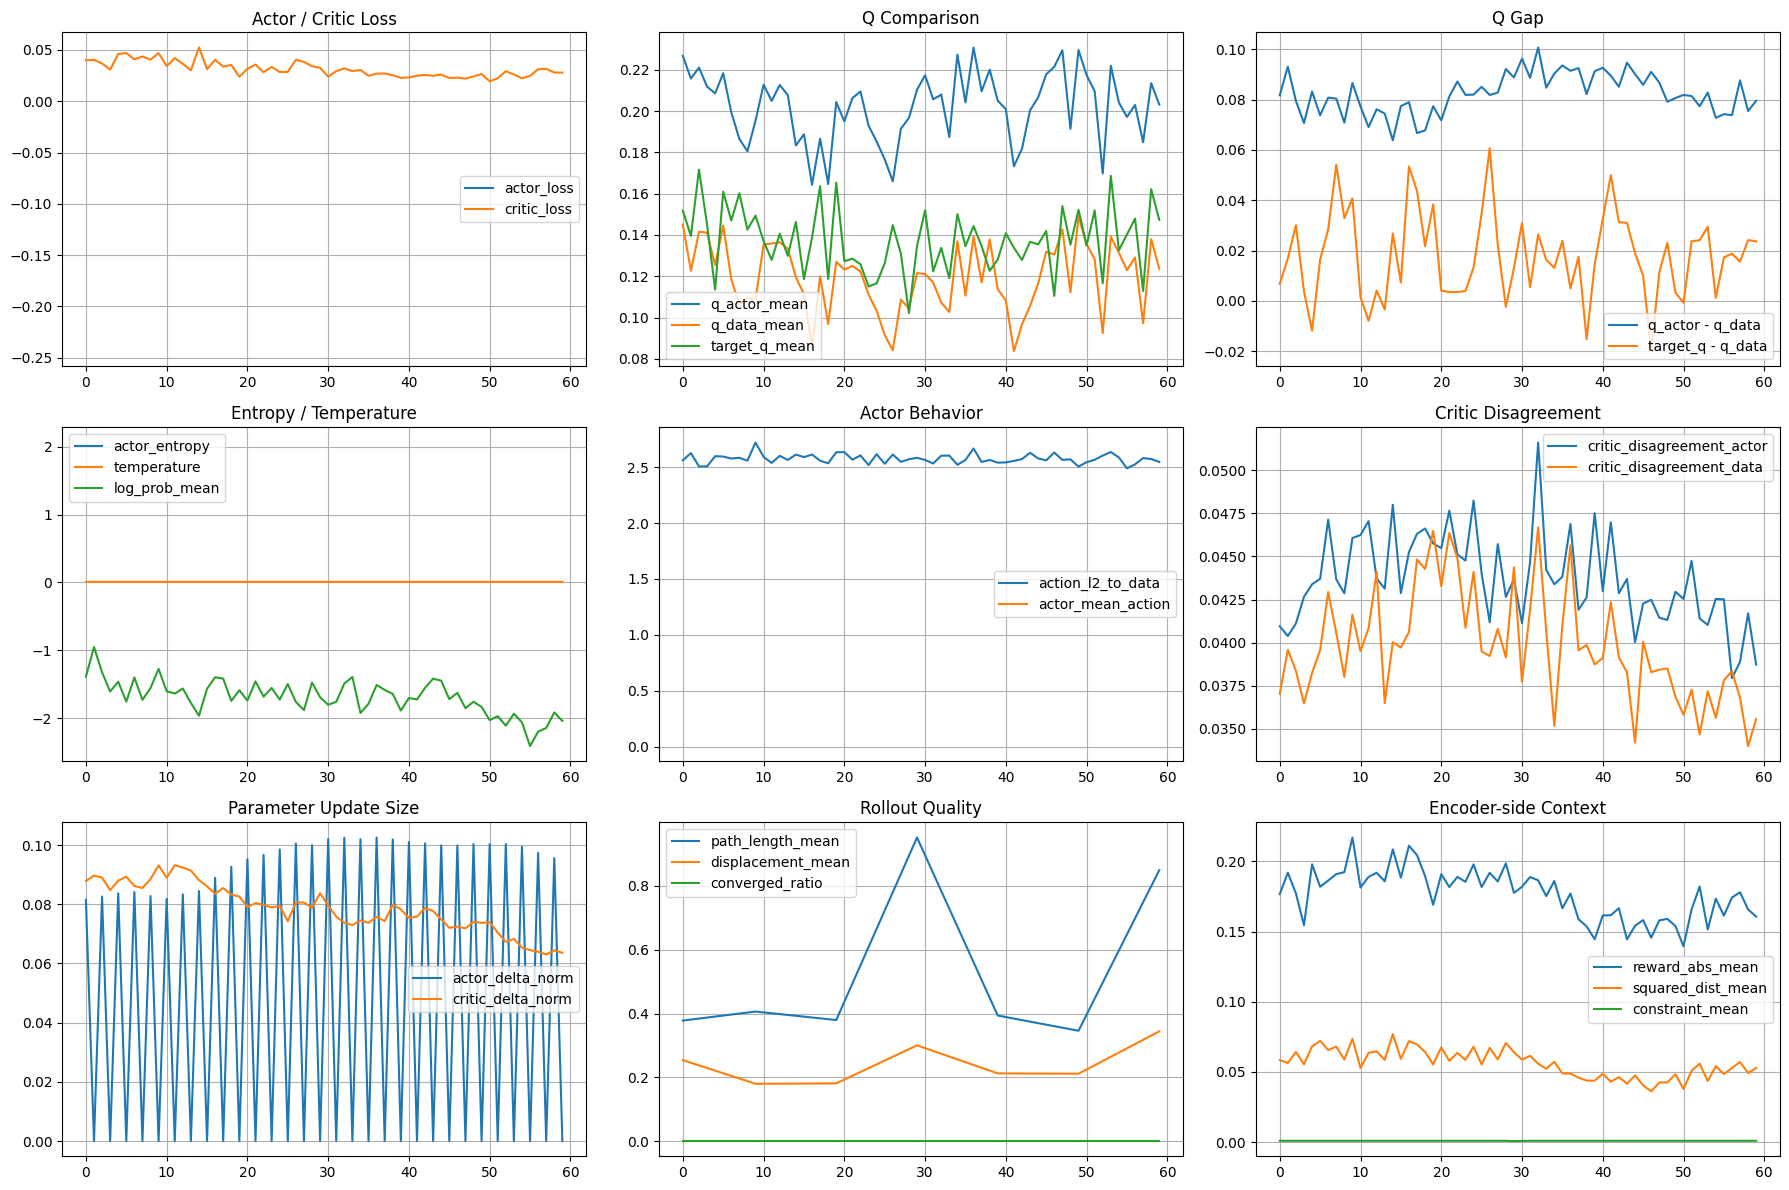

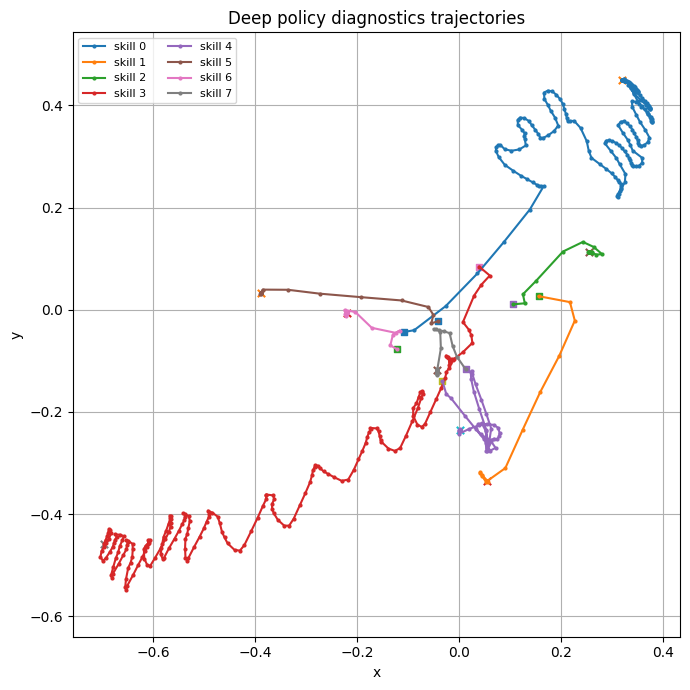

,step,path_length_mean,path_length_max,displacement_mean,converged_ratio
0,0,0.377867,0.575487,0.253975,0.0
1,9,0.406181,0.669089,0.179710,0.0
2,19,0.379599,0.734011,0.180967,0.0
3,29,0.951882,4.065079,0.300281,0.0
4,39,0.393665,0.739290,0.212293,0.0
5,49,0.345951,0.621265,0.211303,0.0
6,59,0.849487,2.470818,0.344017,0.0


,step,reward_mean,reward_abs_mean,squared_dist_mean,constraint_mean,te_obj_mean,skill_encoder_loss,dual_lambda,dual_lambda_loss,temperature_before,...,q_data_mean,q_gap_actor_minus_data,target_q_mean,target_q_minus_q_data,log_prob_mean,critic_disagreement_actor,critic_disagreement_data,action_l2_to_data,actor_delta_norm,critic_delta_norm
55,55,0.004723,0.161343,0.048545,0.001,0.031689,-0.031689,26.963921,0.003295,0.008548,...,0.122957,0.074191,0.140225,0.017268,-2.414402,0.042515,0.037819,2.489479,0.000000,0.064494
56,56,0.012140,0.174182,0.052789,0.001,0.039104,-0.039104,26.961220,0.003294,0.008548,...,0.129161,0.073794,0.147928,0.018767,-2.201043,0.037942,0.038339,2.524978,0.097333,0.063951
57,57,-0.013193,0.177956,0.057096,0.001,0.013768,-0.013768,26.958519,0.003294,0.008546,...,0.097261,0.087637,0.112868,0.015607,-2.147970,0.038887,0.036809,2.580970,0.000000,0.063045
58,58,0.003622,0.165691,0.049285,0.001,0.030580,-0.030580,26.955820,0.003294,0.008546,...,0.138009,0.075448,0.162154,0.024145,-1.917944,0.041698,0.034000,2.572903,0.095619,0.064442
59,59,-0.003327,0.160559,0.052822,0.001,0.023629,-0.023629,26.953121,0.003294,0.008544,...,0.123646,0.079518,0.147309,0.023662,-2.042747,0.038722,0.035569,2.546829,0.000000,0.063608


In [8]:
import math
import matplotlib.pyplot as plt
import pandas as pd

# This cell mutates gaussian_agent further.
deep_num_updates = 60
deep_eval_every = 10
deep_rollout_horizon = 200
deep_num_skills = 8

def _scalar(value):
    if value is None:
        return float("nan")
    if torch.is_tensor(value):
        value = value.detach().float().cpu()
        if value.numel() == 1:
            return float(value.item())
        return float(value.mean().item())
    return float(value)

def _clone_params(module):
    return [param.detach().clone() for param in module.network.parameters()]

def _delta_norm(params_before, module):
    sq_sum = 0.0
    for before, after in zip(params_before, module.network.parameters()):
        diff = after.detach() - before
        sq_sum += float(torch.sum(diff * diff).item())
    return math.sqrt(sq_sum)

def _make_eval_skills(skill_dim, skill_type, num_skills, seed):
    if skill_type == "discrete":
        return np.eye(skill_dim, dtype=np.float32)[:num_skills]

    if skill_dim == 2:
        angles = np.linspace(0.0, 2.0 * np.pi, num_skills, endpoint=False, dtype=np.float32)
        return np.stack([np.cos(angles), np.sin(angles)], axis=1)

    rng = np.random.default_rng(seed)
    skills = rng.standard_normal((num_skills, skill_dim), dtype=np.float32)
    return skills / np.clip(np.linalg.norm(skills, axis=1, keepdims=True), 1e-8, None)

def _rollout_skill_set(eval_agent, env, *, num_skills=8, horizon=200, seed=0):
    skill_dim = int(eval_agent._cfg.skill_dim)
    skill_type = str(eval_agent._cfg.skill_type)
    skills = _make_eval_skills(skill_dim, skill_type, num_skills, seed)

    rows = []
    trajectories = []

    for skill_id, skill in enumerate(skills):
        eval_agent.set_eval_skills(skill[None, :], normalize=(skill_type == "continuous"))
        observations, _ = env.reset()
        prev_transition = {"next_observation": observations}

        positions = []
        actions = []

        for interaction_step in range(horizon):
            action = eval_agent.sample_actions(
                interaction_step=interaction_step,
                prev_transition=prev_transition,
                training=False,
            )
            action = np.squeeze(action)
            next_obs, reward, truncated, terminated, info = env.step(action)

            obs_vec = next_obs[0] if np.asarray(next_obs).ndim > 1 else next_obs
            positions.append(np.asarray(obs_vec[:2], dtype=np.float32))
            actions.append(np.asarray(action, dtype=np.float32))

            prev_transition = {
                "next_observation": next_obs[None, :] if next_obs.ndim == 1 else next_obs
            }

            if truncated or terminated:
                break

        positions = np.asarray(positions, dtype=np.float32)
        actions = np.asarray(actions, dtype=np.float32)

        displacement = float(np.linalg.norm(positions[-1] - positions[0])) if len(positions) >= 2 else 0.0
        path_length = float(np.linalg.norm(np.diff(positions, axis=0), axis=1).sum()) if len(positions) >= 2 else 0.0
        mean_action_std = float(actions.std(axis=0).mean()) if len(actions) > 0 else 0.0

        rows.append({
            "skill_id": skill_id,
            "skill": np.round(skill, 3).tolist(),
            "num_steps": len(actions),
            "displacement": displacement,
            "path_length": path_length,
            "mean_action_std": mean_action_std,
            "converged": bool(mean_action_std < 0.02),
        })
        trajectories.append({
            "skill_id": skill_id,
            "positions": positions,
        })

    return pd.DataFrame(rows), trajectories

def _plot_skill_trajectories(trajectories, title):
    fig, ax = plt.subplots(figsize=(7, 7))
    for traj in trajectories:
        positions = traj["positions"]
        if len(positions) == 0:
            continue
        ax.plot(
            positions[:, 0],
            positions[:, 1],
            marker="o",
            markersize=2,
            linewidth=1.5,
            label=f"skill {traj['skill_id']}",
        )
        ax.scatter(positions[0, 0], positions[0, 1], s=20, marker="s")
        ax.scatter(positions[-1, 0], positions[-1, 1], s=28, marker="x")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.grid(True)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

def deep_policy_diagnose(eval_agent, *, num_updates=60, eval_every=10, horizon=200, num_skills=8):
    device = eval_agent._device
    diag_rows = []
    rollout_rows = []
    last_trajectories = []

    for step in tqdm.tqdm(range(num_updates)):
        batch = sample_from_buffer(eval_agent._replay_buffer, device, return_full_batch=True)
        obs = batch["observation"]
        next_obs = batch["next_observation"]
        skills = batch["skill"]

        intrinsic_reward, squared_distance, constraint_term, lambda_value, skill_encoder_loss = evaluate(
            obs, next_obs, skills, eval_agent, training=True, printi=False
        )

        actor_obs = concat_obs_skill(obs, skills)
        actor_next_obs = concat_obs_skill(next_obs, skills)

        with torch.no_grad():
            actor_obs_all = torch.cat([actor_obs, actor_next_obs], dim=0)
            sampled_actions_all, actor_info_all = eval_agent._actor(
                observations=actor_obs_all,
                training=True,
            )
            sampled_actions, next_sampled_actions = torch.chunk(sampled_actions_all, 2, dim=0)
            sampled_log_probs, next_log_probs = torch.chunk(actor_info_all["log_prob"], 2, dim=0)

            critic_q_actor, _ = eval_agent._critic(
                observations=actor_obs,
                actions=sampled_actions,
                training=False,
            )
            critic_q_data, _ = eval_agent._critic(
                observations=actor_obs,
                actions=batch["action"],
                training=False,
            )
            target_q_next, _ = eval_agent._target_critic(
                observations=actor_next_obs,
                actions=next_sampled_actions,
                training=False,
            )

            min_q_actor = torch.minimum(critic_q_actor[0], critic_q_actor[1])
            min_q_data = torch.minimum(critic_q_data[0], critic_q_data[1])
            min_q_next = torch.minimum(target_q_next[0], target_q_next[1])

            temperature_before = eval_agent._temperature().detach()
            entropy_bonus = temperature_before * next_log_probs
            target_q = intrinsic_reward.detach() + (eval_agent._cfg.gamma ** eval_agent._cfg.n_step) * (
                min_q_next - entropy_bonus
            ) * (1.0 - batch["terminated"])

            critic_disagreement_actor = (critic_q_actor[0] - critic_q_actor[1]).abs().mean()
            critic_disagreement_data = (critic_q_data[0] - critic_q_data[1]).abs().mean()
            action_l2_to_data = torch.norm(sampled_actions - batch["action"], dim=-1).mean()

        reward_mean = intrinsic_reward.detach().mean().item()
        reward_abs_mean = intrinsic_reward.detach().abs().mean().item()
        squared_dist_mean = squared_distance.detach().mean().item()
        constraint_mean = constraint_term.detach().mean().item()
        te_obj_mean = (intrinsic_reward.detach() + lambda_value.detach() * constraint_term.detach()).mean().item()

        eval_agent._skill_encoder.optimizer.zero_grad(set_to_none=True)
        skill_encoder_loss.backward()
        eval_agent._skill_encoder.optimizer.step()
        if eval_agent._skill_encoder.scheduler is not None:
            eval_agent._skill_encoder.scheduler.step()

        with torch.no_grad():
            cst_mean = constraint_term.detach().mean()
        log_lambda = eval_agent._dual_lambda.network.log_temp
        dual_lambda_loss = log_lambda * cst_mean

        assert eval_agent._dual_lambda.optimizer is not None
        eval_agent._dual_lambda.optimizer.zero_grad(set_to_none=True)
        dual_lambda_loss.backward()
        eval_agent._dual_lambda.optimizer.step()
        if eval_agent._dual_lambda.scheduler is not None:
            eval_agent._dual_lambda.scheduler.step()

        with torch.no_grad():
            refreshed_reward, _, _, _, _ = evaluate(obs, next_obs, skills, eval_agent, training=True, printi=False)
            batch["observation"] = actor_obs
            batch["next_observation"] = actor_next_obs
            batch["actor_observation"] = actor_obs
            batch["actor_next_observation"] = actor_next_obs
            batch["reward"] = refreshed_reward

        actor_before = _clone_params(eval_agent._actor)
        critic_before = _clone_params(eval_agent._critic)

        update_info = update_policy(
            batch=batch,
            actor=eval_agent._actor,
            critic=eval_agent._critic,
            target_critic=eval_agent._target_critic,
            temperature=eval_agent._temperature,
            cfg=eval_agent._cfg,
            do_actor_update=(eval_agent._update_step % eval_agent._cfg.actor_update_period == 0),
            device=eval_agent._device,
            grad_scaler=eval_agent._grad_scaler,
        )
        eval_agent._update_step += 1

        actor_delta_norm = _delta_norm(actor_before, eval_agent._actor)
        critic_delta_norm = _delta_norm(critic_before, eval_agent._critic)

        diag_rows.append({
            "step": step,
            "reward_mean": reward_mean,
            "reward_abs_mean": reward_abs_mean,
            "squared_dist_mean": squared_dist_mean,
            "constraint_mean": constraint_mean,
            "te_obj_mean": te_obj_mean,
            "skill_encoder_loss": _scalar(skill_encoder_loss),
            "dual_lambda": _scalar(eval_agent._dual_lambda()),
            "dual_lambda_loss": _scalar(dual_lambda_loss),
            "temperature_before": _scalar(temperature_before),
            "actor_loss": _scalar(update_info.get("actor/loss")),
            "actor_entropy": _scalar(update_info.get("actor/entropy")),
            "actor_mean_action": _scalar(update_info.get("actor/mean_action")),
            "critic_loss": _scalar(update_info.get("critic/loss")),
            "critic_max_entropy_bonus": _scalar(update_info.get("critic/max_entropy_bonus")),
            "temperature_after": _scalar(update_info.get("temperature/value", eval_agent._temperature())),
            "temperature_loss": _scalar(update_info.get("temperature/loss")),
            "q_actor_mean": _scalar(min_q_actor.mean()),
            "q_data_mean": _scalar(min_q_data.mean()),
            "q_gap_actor_minus_data": _scalar((min_q_actor - min_q_data).mean()),
            "target_q_mean": _scalar(target_q.mean()),
            "target_q_minus_q_data": _scalar((target_q - min_q_data).mean()),
            "log_prob_mean": _scalar(sampled_log_probs.mean()),
            "critic_disagreement_actor": _scalar(critic_disagreement_actor),
            "critic_disagreement_data": _scalar(critic_disagreement_data),
            "action_l2_to_data": _scalar(action_l2_to_data),
            "actor_delta_norm": actor_delta_norm,
            "critic_delta_norm": critic_delta_norm,
        })

        if step == 0 or (step + 1) % eval_every == 0 or step == num_updates - 1:
            rollout_df, last_trajectories = _rollout_skill_set(
                eval_agent,
                metra_env,
                num_skills=num_skills,
                horizon=horizon,
                seed=cfg.seed,
            )
            rollout_rows.append({
                "step": step,
                "path_length_mean": float(rollout_df["path_length"].mean()),
                "path_length_max": float(rollout_df["path_length"].max()),
                "displacement_mean": float(rollout_df["displacement"].mean()),
                "converged_ratio": float(rollout_df["converged"].mean()),
            })

    return pd.DataFrame(diag_rows), pd.DataFrame(rollout_rows), last_trajectories

deep_policy_df, deep_rollout_df, deep_skill_trajectories = deep_policy_diagnose(
    gaussian_agent,
    num_updates=deep_num_updates,
    eval_every=deep_eval_every,
    horizon=deep_rollout_horizon,
    num_skills=deep_num_skills,
    )

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

axes[0].plot(deep_policy_df["step"], deep_policy_df["actor_loss"], label="actor_loss")
axes[0].plot(deep_policy_df["step"], deep_policy_df["critic_loss"], label="critic_loss")
axes[0].set_title("Actor / Critic Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(deep_policy_df["step"], deep_policy_df["q_actor_mean"], label="q_actor_mean")
axes[1].plot(deep_policy_df["step"], deep_policy_df["q_data_mean"], label="q_data_mean")
axes[1].plot(deep_policy_df["step"], deep_policy_df["target_q_mean"], label="target_q_mean")
axes[1].set_title("Q Comparison")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(deep_policy_df["step"], deep_policy_df["q_gap_actor_minus_data"], label="q_actor - q_data")
axes[2].plot(deep_policy_df["step"], deep_policy_df["target_q_minus_q_data"], label="target_q - q_data")
axes[2].set_title("Q Gap")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(deep_policy_df["step"], deep_policy_df["actor_entropy"], label="actor_entropy")
axes[3].plot(deep_policy_df["step"], deep_policy_df["temperature_after"], label="temperature")
axes[3].plot(deep_policy_df["step"], deep_policy_df["log_prob_mean"], label="log_prob_mean")
axes[3].set_title("Entropy / Temperature")
axes[3].legend()
axes[3].grid(True)

axes[4].plot(deep_policy_df["step"], deep_policy_df["action_l2_to_data"], label="action_l2_to_data")
axes[4].plot(deep_policy_df["step"], deep_policy_df["actor_mean_action"], label="actor_mean_action")
axes[4].set_title("Actor Behavior")
axes[4].legend()
axes[4].grid(True)

axes[5].plot(deep_policy_df["step"], deep_policy_df["critic_disagreement_actor"], label="critic_disagreement_actor")
axes[5].plot(deep_policy_df["step"], deep_policy_df["critic_disagreement_data"], label="critic_disagreement_data")
axes[5].set_title("Critic Disagreement")
axes[5].legend()
axes[5].grid(True)

axes[6].plot(deep_policy_df["step"], deep_policy_df["actor_delta_norm"], label="actor_delta_norm")
axes[6].plot(deep_policy_df["step"], deep_policy_df["critic_delta_norm"], label="critic_delta_norm")
axes[6].set_title("Parameter Update Size")
axes[6].legend()
axes[6].grid(True)

axes[7].plot(deep_rollout_df["step"], deep_rollout_df["path_length_mean"], label="path_length_mean")
axes[7].plot(deep_rollout_df["step"], deep_rollout_df["displacement_mean"], label="displacement_mean")
axes[7].plot(deep_rollout_df["step"], deep_rollout_df["converged_ratio"], label="converged_ratio")
axes[7].set_title("Rollout Quality")
axes[7].legend()
axes[7].grid(True)

axes[8].plot(deep_policy_df["step"], deep_policy_df["reward_abs_mean"], label="reward_abs_mean")
axes[8].plot(deep_policy_df["step"], deep_policy_df["squared_dist_mean"], label="squared_dist_mean")
axes[8].plot(deep_policy_df["step"], deep_policy_df["constraint_mean"], label="constraint_mean")
axes[8].set_title("Encoder-side Context")
axes[8].legend()
axes[8].grid(True)

plt.tight_layout()
plt.show()

_plot_skill_trajectories(deep_skill_trajectories, "Deep policy diagnostics trajectories")

display(deep_rollout_df)
deep_policy_df.tail()